Shape: (366354, 7)
     IDpol  Year  NbClaim      Expo   Usage    VehType   VehPower
0  PN24816  1999        0  0.297814  Usage5  VehType10  VehPower3
1  PN24816  2000        0  0.997268  Usage5  VehType10  VehPower3
2  PN24816  2001        0  0.997268  Usage5  VehType10  VehPower3
3  PN24816  2002        0  0.997268  Usage5  VehType10  VehPower3
4  PN24816  2003        0  1.000000  Usage5  VehType10  VehPower3
IDpol        object
Year          int64
NbClaim       int64
Expo        float64
Usage        object
VehType      object
VehPower     object
dtype: object

===== Sequence length distribution =====
count    72749.000000
mean         5.035863
std          2.324731
min          1.000000
25%          3.000000
50%          5.000000
75%          7.000000
max          9.000000
Name: n_years, dtype: float64

Value counts (years tracked -> number of policyholders):
n_years
1     1357
2    11533
3    10342
4     9797
5     9643
6     8457
7     7470
8     6880
9     7270
Name: count, dtype

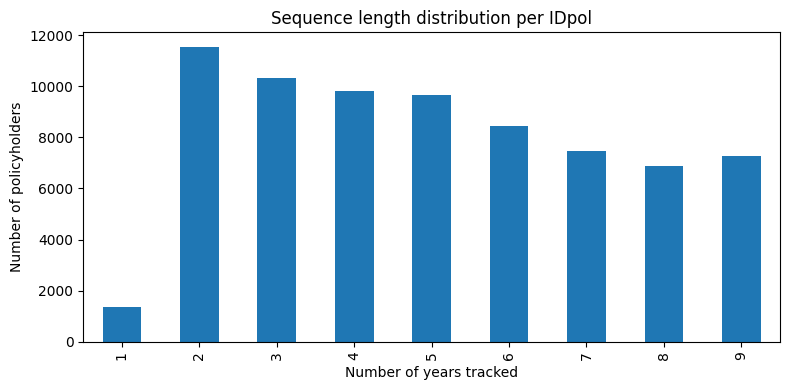


===== Single vs multi history split =====
Single-history policyholders :   1,357 (1.9%)
Multi-history  policyholders :  71,392 (98.1%)
Single-history rows          :   1,357
Multi-history  rows          : 364,997

Saved: fremotor_single_history.csv, fremotor_multi_history.csv

===== Label distribution (NbClaim) =====
NbClaim
0     319952
1      37034
2       7276
3       1627
4        342
5         96
6         23
7          3
16         1
Name: count, dtype: int64

Claim rate (NbClaim >= 1): 12.67%

Binary label distribution (multi-history only):
Label
0    318744
1     46253
Name: count, dtype: int64
Positive rate: 12.67%

===== Derived feature preview =====
      IDpol  Year  YearGap  Label  PrevLabel  LabelChanged
0  PN100006  2003        0      0        NaN           NaN
1  PN100006  2004        1      0        0.0           0.0
2  PN100006  2005        2      0        0.0           0.0
3  PN100006  2006        3      0        0.0           0.0
4  PN100006  2007        4      0  

In [1]:
# ============================================================
# Notebook    : 01_eda_preprocessing.ipynb
# Description : EDA and longitudinal sequence construction
#               - Inspect sequence length distribution per IDpol
#               - Split single-record vs multi-year policyholders
#               - Generate derived features for Transformer input
# ============================================================


# ============================================================
# 1. Common imports
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)


# ============================================================
# 2. Load fremotor2freq9907b
#    - PrimaryKey : IDpol
#    - TestDate   : Year
#    - Label      : NbClaim
# ============================================================
df = pd.read_csv("data/fremotor2freq9907b.csv")

print("Shape:", df.shape)
print(df.head())
print(df.dtypes)


# ============================================================
# 3. Sequence length distribution per IDpol
#    - Counts how many years each policyholder was tracked
#    - Equivalent to checking A-only vs A+B history depth
# ============================================================
seq_len = df.groupby("IDpol").size().rename("n_years")

print("\n===== Sequence length distribution =====")
print(seq_len.describe())
print("\nValue counts (years tracked -> number of policyholders):")
print(seq_len.value_counts().sort_index())

plt.figure(figsize=(8, 4))
seq_len.value_counts().sort_index().plot(kind="bar")
plt.xlabel("Number of years tracked")
plt.ylabel("Number of policyholders")
plt.title("Sequence length distribution per IDpol")
plt.tight_layout()
plt.savefig("data/seq_length_distribution.png")
plt.show()


# ============================================================
# 4. Split single-record vs multi-year policyholders
#    - single_history : only 1 year of record (cannot form a sequence)
#    - multi_history   : 2+ years of record (usable for longitudinal model)
# ============================================================
single_ids = seq_len[seq_len == 1].index
multi_ids  = seq_len[seq_len >= 2].index

df_single = df[df["IDpol"].isin(single_ids)].copy()
df_multi  = df[df["IDpol"].isin(multi_ids)].copy()

print("\n===== Single vs multi history split =====")
print(f"Single-history policyholders : {len(single_ids):>7,} ({len(single_ids)/len(seq_len)*100:.1f}%)")
print(f"Multi-history  policyholders : {len(multi_ids):>7,} ({len(multi_ids)/len(seq_len)*100:.1f}%)")
print(f"Single-history rows          : {df_single.shape[0]:>7,}")
print(f"Multi-history  rows          : {df_multi.shape[0]:>7,}")

df_single.to_csv("data/fremotor_single_history.csv", index=False)
df_multi.to_csv("data/fremotor_multi_history.csv", index=False)
print("\nSaved: fremotor_single_history.csv, fremotor_multi_history.csv")


# ============================================================
# 5. Label distribution check (NbClaim)
#    - Confirms class imbalance, same issue as original DACON
#      Label(0/1) variable mentioned in the proposal
# ============================================================
print("\n===== Label distribution (NbClaim) =====")
print(df["NbClaim"].value_counts().sort_index())
print(f"\nClaim rate (NbClaim >= 1): {(df['NbClaim'] >= 1).mean()*100:.2f}%")

# Binary label version for downstream classification tasks
df_multi["Label"] = (df_multi["NbClaim"] >= 1).astype(int)
print("\nBinary label distribution (multi-history only):")
print(df_multi["Label"].value_counts())
print(f"Positive rate: {df_multi['Label'].mean()*100:.2f}%")


# ============================================================
# 6. Sort by IDpol + Year, generate derived features
#    - YearGap        : interval since first observation
#    - PrevLabel       : previous year's label (for sequence model)
#    - LabelChanged    : whether label flipped vs previous year
# ============================================================
df_multi = df_multi.sort_values(["IDpol", "Year"]).reset_index(drop=True)

df_multi["YearGap"] = df_multi.groupby("IDpol")["Year"].transform(lambda x: x - x.min())
df_multi["PrevLabel"] = df_multi.groupby("IDpol")["Label"].shift(1)
df_multi["LabelChanged"] = (df_multi["Label"] != df_multi["PrevLabel"]).astype(int)
df_multi.loc[df_multi["PrevLabel"].isna(), "LabelChanged"] = np.nan  # first record has no previous label

print("\n===== Derived feature preview =====")
print(df_multi[["IDpol", "Year", "YearGap", "Label", "PrevLabel", "LabelChanged"]].head(10))

df_multi.to_csv("data/fremotor_multi_history_features.csv", index=False)
print("\nSaved: fremotor_multi_history_features.csv")


# ============================================================
# 7. Summary check
# ============================================================
print("\n===== Preprocessing Summary =====")
print(f"Total policyholders       : {len(seq_len):>7,}")
print(f"  - Single history (excl.) : {len(single_ids):>7,}")
print(f"  - Multi history  (used)  : {len(multi_ids):>7,}")
print(f"Total rows used for model : {df_multi.shape[0]:>7,}")
print(f"Overall positive rate     : {df_multi['Label'].mean()*100:.2f}%")
print("==================================")